# Gait Anomaly Detection / Isolation Forest

A drop-in alternative to the 1D Convolutional Autoencoder approach, using **Isolation Forest** — a tree-based, unsupervised anomaly detector that works by measuring how easily a sample can be isolated from the rest. No labels required.

> **Goal:** Learn what *normal* walking gait looks like from shoe-insert IMU Euler angles (yaw, pitch, roll). Anomalies are detected as gait cycles that are easily isolated from the normal population — no labels required.

This notebook is the runnable pipeline: synthetic data → gait-cycle segmentation → feature extraction → Isolation Forest training → anomaly flagging. Run it top to bottom.

---

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.signal import find_peaks, butter, filtfilt
from scipy.interpolate import interp1d
from pathlib import Path
import warnings

from sklearn.ensemble import IsolationForest
from sklearn.preprocessing import StandardScaler
from sklearn.manifold import TSNE
from sklearn.decomposition import PCA
from sklearn.metrics import classification_report
import joblib

warnings.filterwarnings("ignore")
plt.rcParams.update({
    "figure.figsize": (14, 4),
    "axes.grid": True,
    "grid.alpha": 0.3,
})
print("scikit-learn Isolation Forest pipeline ready")

scikit-learn Isolation Forest pipeline ready


## 1) Configuration

All tuneable parameters in one place. The segmentation parameters (`MIN_STRIDE_SAMPLES`, `PITCH_PEAK_PROMINENCE`) depend on your IMU's sampling rate and mounting. The Isolation Forest parameters (`N_ESTIMATORS`, `CONTAMINATION`) control model sensitivity.

In [3]:
# ── Sensor and segmentation ─────────────────────────────────────
SAMPLING_RATE         = 100        # Hz (match your IMU)
CYCLE_LENGTH          = 128        # resampled timesteps per cycle
MIN_STRIDE_SAMPLES    = 50         # min samples between heel strikes
PITCH_PEAK_PROMINENCE = 8.0        # degrees, tune per sensor mount
LOWPASS_CUTOFF        = 15.0       # Hz (set to 0 to disable)

# ── Feature extraction ─────────────────────────────────────────
# Choose which feature set to feed the model.
# 'statistical'  : 27 hand-crafted stats per channel (mean, std, range, peaks, …)
# 'pca_flat'     : PCA of flattened raw cycles (keeps most variance)
# 'both'         : concatenation of the two
FEATURE_MODE = "both"              # 'statistical' | 'pca_flat' | 'both'
PCA_COMPONENTS = 20               # used when FEATURE_MODE includes 'pca_flat'

# ── Isolation Forest ───────────────────────────────────────────
N_ESTIMATORS  = 200               # number of trees
CONTAMINATION = 0.05              # expected anomaly fraction (or 'auto')
MAX_SAMPLES   = "auto"            # samples per tree ('auto' = min(256, n))
MAX_FEATURES  = 1.0               # feature fraction per tree

# ── Misc ───────────────────────────────────────────────────────
SEED = 42
np.random.seed(SEED)

## 2) Data loading

### 2a. Synthetic data generator *(for testing)*
Creates a realistic foot-mounted IMU signal. Skip once you have real CSV files.

In [4]:
def generate_synthetic_gait(duration_s=120, fs=100, inject_anomalies=True):
    """
    Generate a DataFrame that mimics a foot-mounted IMU recording.

    Parameters
    ----------
    duration_s : float   - total recording length in seconds
    fs         : int     - sampling rate (Hz)
    inject_anomalies : bool - if True, corrupt ~5% of strides

    Returns
    -------
    pd.DataFrame with columns: Relative timestamp, yaw, pitch, roll
    """
    n = int(duration_s * fs)
    t = np.arange(n) / fs
    stride_freq = 0.9                       # ~1.1 s per stride

    # pitch: dominant sagittal-plane signal
    pitch = (15.0 * np.sin(2 * np.pi * stride_freq * t)
           +  7.0 * np.sin(4 * np.pi * stride_freq * t - 0.4)
           +  2.5 * np.sin(6 * np.pi * stride_freq * t + 0.2))

    # roll: smaller frontal-plane oscillation
    roll  = (5.0 * np.sin(2 * np.pi * stride_freq * t + 0.5)
           + 2.0 * np.sin(4 * np.pi * stride_freq * t + 0.3))

    # yaw: slow drift + small oscillation
    yaw   = (0.005 * t
           + 3.0 * np.sin(2 * np.pi * stride_freq * t + 1.0))

    # add sensor noise
    pitch += np.random.randn(n) * 0.8
    roll  += np.random.randn(n) * 0.5
    yaw   += np.random.randn(n) * 0.4

    # inject a few anomalous strides
    if inject_anomalies:
        stride_samples = int(fs / stride_freq)
        n_strides = n // stride_samples
        anomaly_idxs = np.random.choice(n_strides, size=max(1, n_strides // 20), replace=False)
        for si in anomaly_idxs:
            s = si * stride_samples
            e = min(s + stride_samples, n)
            kind = np.random.choice(["asymmetry", "foot_drop", "stumble"])
            if kind == "asymmetry":
                roll[s:e] += 12 * np.sin(2 * np.pi * stride_freq * t[s:e])
            elif kind == "foot_drop":
                pitch[s:e] *= 0.35
            else:
                pitch[s:e] += np.random.randn(e - s) * 8

    return pd.DataFrame({
        "Relative timestamp": t,
        "yaw": yaw,
        "pitch": pitch,
        "roll": roll,
    })

# Generate a 2-minute synthetic recording to test the pipeline
df = generate_synthetic_gait(duration_s=120, fs=SAMPLING_RATE)
print(f"Synthetic data: {len(df)} samples, {len(df)/SAMPLING_RATE:.1f} s")
df.head()

Synthetic data: 12000 samples, 120.0 s


,Relative timestamp,yaw,pitch,roll
0,0.00,2.255864,-0.641159,3.575575
1,0.01,2.326519,-0.119175,2.504700
2,0.02,3.261477,0.799504,3.717612
3,0.03,3.507753,1.733830,4.275967
4,0.04,2.452277,1.913760,4.694870


### 2b. Load your real CSV

Uncomment the cell below and point it at your file. Expected format: four columns — `Relative timestamp, yaw, pitch, roll` (floats, angles in degrees).

In [5]:
# Uncomment to load your own data
# DATA_PATH = Path("your_recording.csv")
# df = pd.read_csv(DATA_PATH)
#
# # Infer sampling rate from timestamps
# dt = df["Relative timestamp"].diff().median()
# SAMPLING_RATE = int(round(1.0 / dt))
# print(f"Loaded {len(df)} samples at ~{SAMPLING_RATE} Hz "
#       f"({len(df)/SAMPLING_RATE:.1f} s)")
# df.head()

## 3) Visualise raw signals

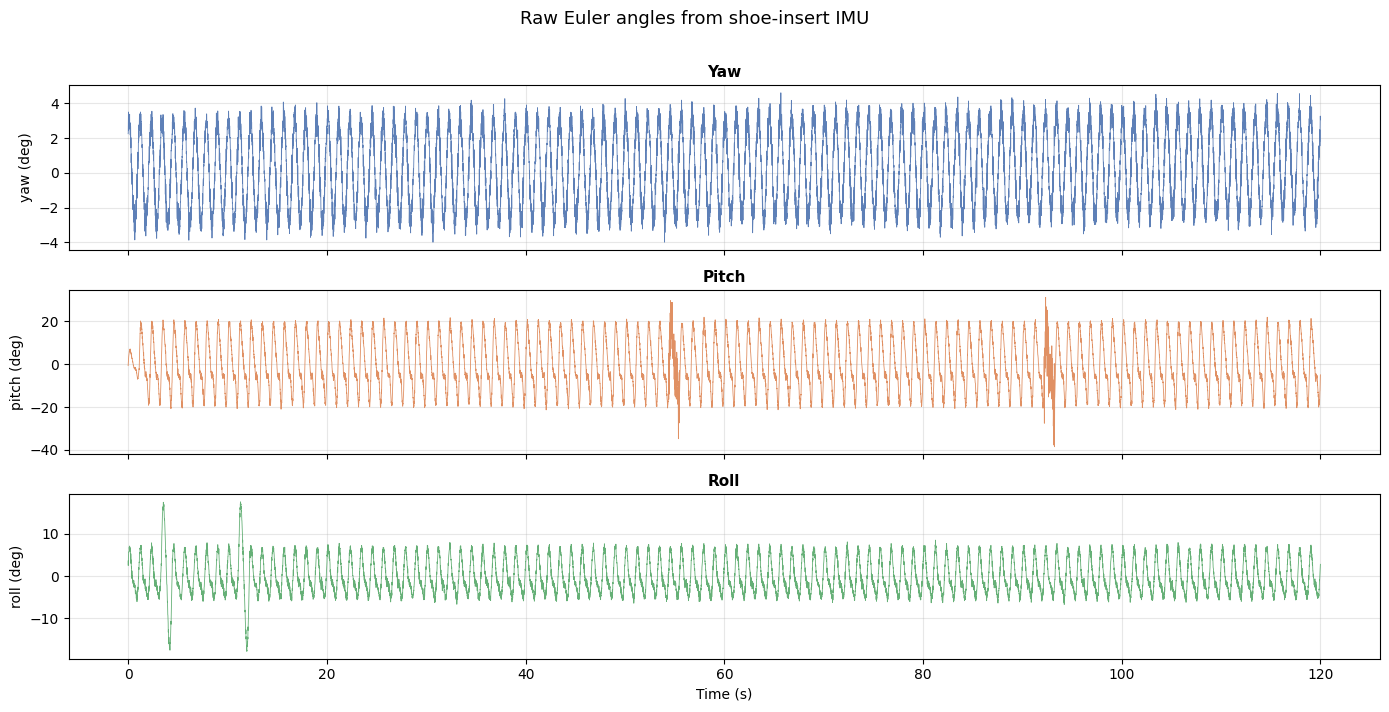

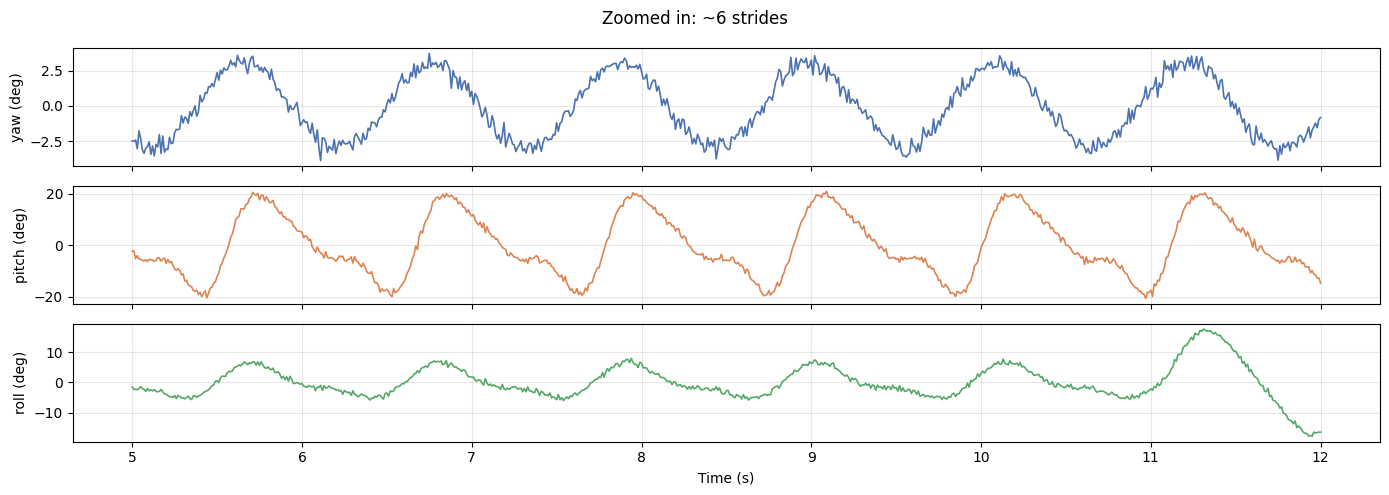

In [6]:
fig, axes = plt.subplots(3, 1, figsize=(14, 7), sharex=True)
t = df["Relative timestamp"].values

for ax, col, color in zip(axes, ["yaw", "pitch", "roll"],
                           ["#4C72B0", "#DD8452", "#55A868"]):
    ax.plot(t, df[col].values, color=color, lw=0.6, alpha=0.9)
    ax.set_ylabel(f"{col} (deg)")
    ax.set_title(col.capitalize(), fontsize=11, fontweight="bold")

axes[-1].set_xlabel("Time (s)")
fig.suptitle("Raw Euler angles from shoe-insert IMU", fontsize=13, y=1.01)
fig.tight_layout()
plt.show()

# Zoom into a few strides to see the waveform shape
fig, axes = plt.subplots(3, 1, figsize=(14, 5), sharex=True)
mask = (t >= 5) & (t <= 12)
for ax, col, color in zip(axes, ["yaw", "pitch", "roll"],
                           ["#4C72B0", "#DD8452", "#55A868"]):
    ax.plot(t[mask], df[col].values[mask], color=color, lw=1.2)
    ax.set_ylabel(f"{col} (deg)")
axes[-1].set_xlabel("Time (s)")
fig.suptitle("Zoomed in: ~6 strides", fontsize=12)
fig.tight_layout()
plt.show()

## 4) Low-pass filter (optional)

Set `LOWPASS_CUTOFF = 0` to skip.

In [7]:
def lowpass(signal, cutoff, fs, order=4):
    if cutoff <= 0 or cutoff >= fs / 2:
        return signal
    b, a = butter(order, cutoff / (fs / 2), btype="low")
    return filtfilt(b, a, signal)

angles = np.column_stack([df["yaw"].values,
                          df["pitch"].values,
                          df["roll"].values])      # (N, 3)
timestamps = df["Relative timestamp"].values

if LOWPASS_CUTOFF > 0:
    for ch in range(3):
        angles[:, ch] = lowpass(angles[:, ch], LOWPASS_CUTOFF, SAMPLING_RATE)
    print(f"Applied {LOWPASS_CUTOFF} Hz low-pass filter")
else:
    print("Low-pass filter disabled")

Applied 15.0 Hz low-pass filter


## 5) Gait-cycle segmentation

Detect **heel strikes** as prominent peaks in the pitch channel. Each pair of consecutive peaks defines one gait cycle.

> **Tip:** If the segmentation looks off, tweak `PITCH_PEAK_PROMINENCE` and `MIN_STRIDE_SAMPLES` and re-check the plot below.

In [8]:
pitch = angles[:, 1]                           # column index 1 = pitch

# Detect heel strikes as local maxima in pitch
heel_strikes, properties = find_peaks(
    pitch,
    distance=MIN_STRIDE_SAMPLES,
    prominence=PITCH_PEAK_PROMINENCE,
)

print(f"Detected {len(heel_strikes)} heel strikes "
      f"-> {len(heel_strikes) - 1} gait cycles")

# Quick sanity check on stride durations
stride_durations = np.diff(timestamps[heel_strikes])
print(f"Stride duration: "
      f"mean={stride_durations.mean():.3f} s, "
      f"std={stride_durations.std():.3f} s, "
      f"range=[{stride_durations.min():.3f}, {stride_durations.max():.3f}] s")

Detected 108 heel strikes -> 107 gait cycles
Stride duration: mean=1.101 s, std=0.084 s, range=[0.500, 1.180] s


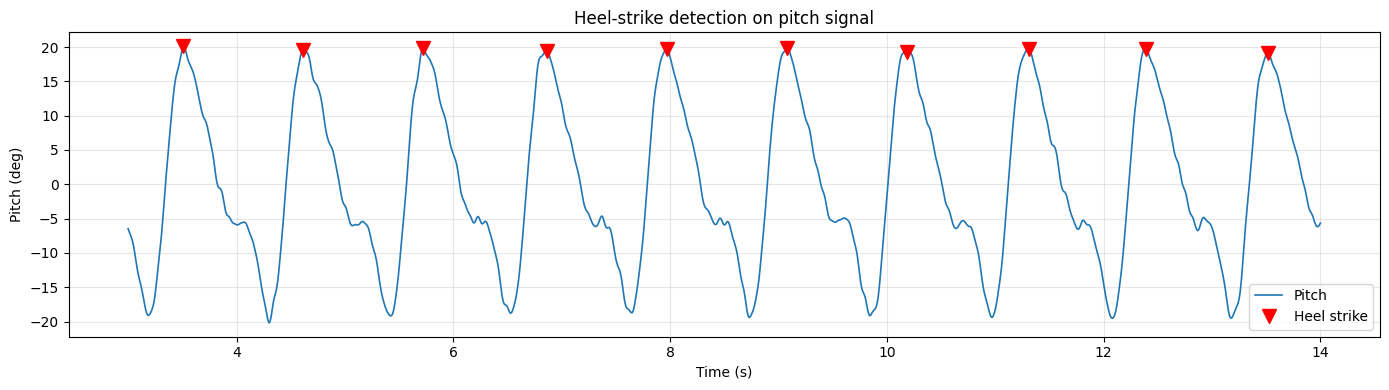

In [9]:
fig, ax = plt.subplots(figsize=(14, 4))
t_sec = timestamps

# Show a zoomed segment so individual peaks are visible
view_start, view_end = 3.0, 14.0
mask = (t_sec >= view_start) & (t_sec <= view_end)

ax.plot(t_sec[mask], pitch[mask], lw=1.2, label="Pitch")

hs_mask = (t_sec[heel_strikes] >= view_start) & (t_sec[heel_strikes] <= view_end)
ax.plot(t_sec[heel_strikes[hs_mask]], pitch[heel_strikes[hs_mask]],
        "rv", ms=10, label="Heel strike")

ax.set_xlabel("Time (s)")
ax.set_ylabel("Pitch (deg)")
ax.set_title("Heel-strike detection on pitch signal")
ax.legend()
fig.tight_layout()
plt.show()

## 6) Extract and resample gait cycles

Each cycle gets resampled to `CYCLE_LENGTH` timesteps using linear interpolation so all inputs are fixed-size.

In [10]:
def extract_cycles(angles, heel_strikes, target_len):
    """
    Cut the angle array at heel-strike indices and resample
    each cycle to target_len timesteps.

    Returns
    -------
    cycles  : np.ndarray, shape (n_cycles, target_len, 3)
    lengths : list[int] - original sample count per cycle
    """
    cycles, lengths = [], []
    for i in range(len(heel_strikes) - 1):
        start = heel_strikes[i]
        end   = heel_strikes[i + 1]
        seg   = angles[start:end]               # (variable_len, 3)
        n     = len(seg)
        if n < 20:                               # skip tiny fragments
            continue
        x_old = np.linspace(0, 1, n)
        x_new = np.linspace(0, 1, target_len)
        resampled = np.zeros((target_len, 3))
        for ch in range(3):
            resampled[:, ch] = interp1d(x_old, seg[:, ch], kind="linear")(x_new)
        cycles.append(resampled)
        lengths.append(n)
    return np.array(cycles, dtype=np.float32), lengths

cycles, orig_lengths = extract_cycles(angles, heel_strikes, CYCLE_LENGTH)
print(f"Extracted {len(cycles)} gait cycles, each resampled to "
      f"{CYCLE_LENGTH} timesteps x {cycles.shape[2]} channels")

Extracted 107 gait cycles, each resampled to 128 timesteps x 3 channels


### Channel-wise z-score normalisation

Computed per channel across all cycles. Save these stats — they're required at inference time.

In [11]:
# Compute stats across (n_cycles, timesteps) per channel
chan_mean = cycles.mean(axis=(0, 1))            # shape (3,)
chan_std  = cycles.std(axis=(0, 1))             # shape (3,)
chan_std[chan_std < 1e-8] = 1.0                 # guard against zero-variance

cycles_norm = (cycles - chan_mean) / chan_std

print("Channel statistics (before normalisation):")
for i, name in enumerate(["yaw", "pitch", "roll"]):
    print(f"  {name:>5s}  mean={chan_mean[i]:+.2f} deg  std={chan_std[i]:.2f} deg")

Channel statistics (before normalisation):
    yaw  mean=+0.29 deg  std=2.13 deg
  pitch  mean=-0.06 deg  std=11.82 deg
   roll  mean=-0.01 deg  std=4.10 deg


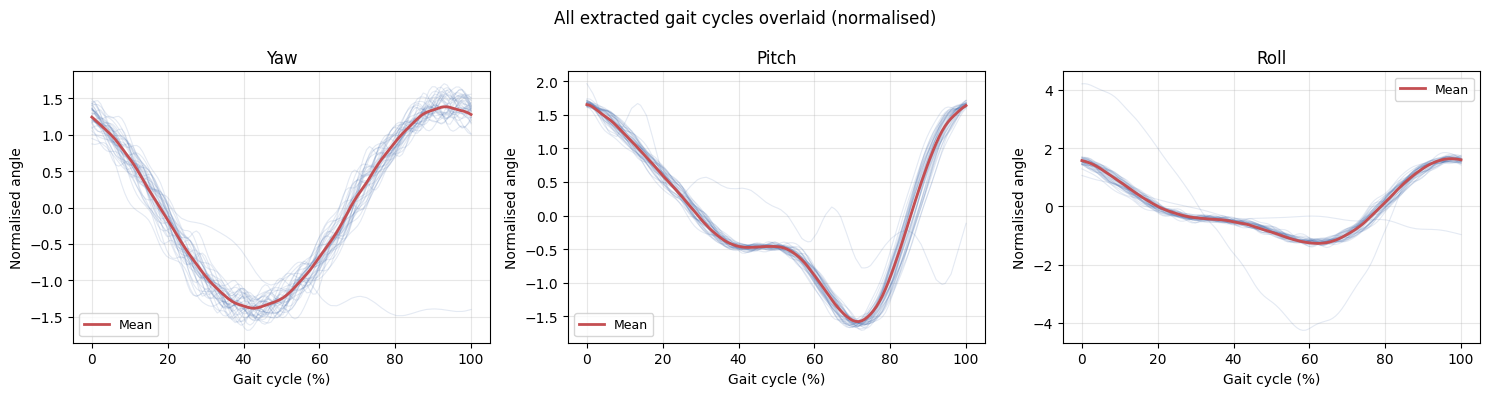

In [12]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
x = np.linspace(0, 100, CYCLE_LENGTH)          # % of gait cycle

for ch, (ax, name) in enumerate(zip(axes, ["Yaw", "Pitch", "Roll"])):
    for c in cycles_norm[::3]:                  # plot every 3rd for clarity
        ax.plot(x, c[:, ch], alpha=0.15, lw=0.8, color="#4C72B0")
    ax.plot(x, cycles_norm[:, :, ch].mean(axis=0),
            color="#C44E52", lw=2, label="Mean")
    ax.set_title(name)
    ax.set_xlabel("Gait cycle (%)")
    ax.set_ylabel("Normalised angle")
    ax.legend(fontsize=9)

fig.suptitle("All extracted gait cycles overlaid (normalised)", fontsize=12)
fig.tight_layout()
plt.show()

## 7) Feature extraction

Unlike the autoencoder, Isolation Forest operates on a **flat feature vector** per cycle. Two complementary strategies are available:

- **Statistical** — 9 hand-crafted features per channel (mean, std, min, max, range, RMS, peak count, dominant frequency power, waveform asymmetry) → 27-d vector. Interpretable and compact.
- **PCA of flattened cycles** — the raw 384-d (128 × 3) vector projected to the top `PCA_COMPONENTS` principal components. Captures shape information that stats might miss.
- **Both** — concatenation, giving the richest representation.

Switch between them via `FEATURE_MODE` in Section 1.

In [13]:
def extract_statistical_features(cycles_norm):
    """
    Compute 9 features per channel (27 total) for each gait cycle.

    Parameters
    ----------
    cycles_norm : np.ndarray, shape (N, T, 3)

    Returns
    -------
    features : np.ndarray, shape (N, 27)
    feature_names : list[str]
    """
    N, T, C = cycles_norm.shape
    feat_names = []
    feat_blocks = []

    for ch, ch_name in enumerate(["yaw", "pitch", "roll"]):
        sig = cycles_norm[:, :, ch]            # (N, T)

        f_mean  = sig.mean(axis=1)
        f_std   = sig.std(axis=1)
        f_min   = sig.min(axis=1)
        f_max   = sig.max(axis=1)
        f_range = f_max - f_min
        f_rms   = np.sqrt((sig ** 2).mean(axis=1))

        # Peak count: local maxima per cycle
        f_npeaks = np.array([
            len(find_peaks(row, prominence=0.3)[0]) for row in sig
        ], dtype=float)

        # Dominant frequency power (via FFT)
        fft_mag = np.abs(np.fft.rfft(sig, axis=1))
        f_dom_pwr = fft_mag[:, 1:T // 2].max(axis=1)   # skip DC

        # Waveform asymmetry: area under first half vs second half
        half = T // 2
        f_asym = sig[:, :half].mean(axis=1) - sig[:, half:].mean(axis=1)

        block = np.column_stack([
            f_mean, f_std, f_min, f_max, f_range,
            f_rms, f_npeaks, f_dom_pwr, f_asym
        ])
        feat_blocks.append(block)
        feat_names += [
            f"{ch_name}_mean", f"{ch_name}_std", f"{ch_name}_min",
            f"{ch_name}_max", f"{ch_name}_range", f"{ch_name}_rms",
            f"{ch_name}_npeaks", f"{ch_name}_dom_pwr", f"{ch_name}_asym",
        ]

    features = np.hstack(feat_blocks)             # (N, 27)
    return features, feat_names


stat_features, stat_feature_names = extract_statistical_features(cycles_norm)
print(f"Statistical features: {stat_features.shape}  ({len(stat_feature_names)} features per cycle)")
print("  Feature names:", stat_feature_names)

Statistical features: (107, 27)  (27 features per cycle)
  Feature names: ['yaw_mean', 'yaw_std', 'yaw_min', 'yaw_max', 'yaw_range', 'yaw_rms', 'yaw_npeaks', 'yaw_dom_pwr', 'yaw_asym', 'pitch_mean', 'pitch_std', 'pitch_min', 'pitch_max', 'pitch_range', 'pitch_rms', 'pitch_npeaks', 'pitch_dom_pwr', 'pitch_asym', 'roll_mean', 'roll_std', 'roll_min', 'roll_max', 'roll_range', 'roll_rms', 'roll_npeaks', 'roll_dom_pwr', 'roll_asym']


PCA features: (107, 20)
Variance explained by 20 components: 96.9%


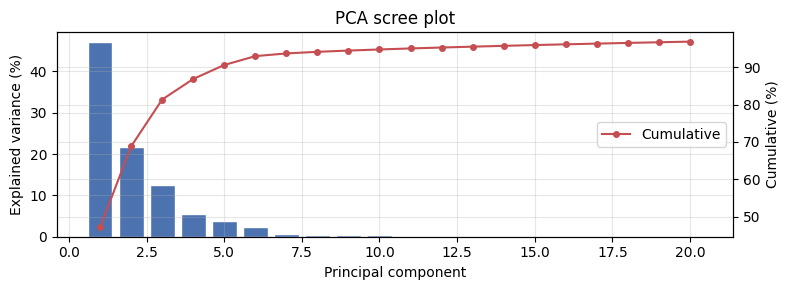

In [14]:
# Flatten cycles and reduce dimensionality with PCA
flat_cycles = cycles_norm.reshape(len(cycles_norm), -1)   # (N, 384)

pca = PCA(n_components=PCA_COMPONENTS, random_state=SEED)
pca_features = pca.fit_transform(flat_cycles)             # (N, PCA_COMPONENTS)

explained = pca.explained_variance_ratio_.cumsum()[-1]
print(f"PCA features: {pca_features.shape}")
print(f"Variance explained by {PCA_COMPONENTS} components: {100*explained:.1f}%")

# Scree plot
fig, ax = plt.subplots(figsize=(8, 3))
ax.bar(range(1, PCA_COMPONENTS + 1), pca.explained_variance_ratio_ * 100,
       color="#4C72B0", edgecolor="white")
ax2 = ax.twinx()
ax2.plot(range(1, PCA_COMPONENTS + 1),
         pca.explained_variance_ratio_.cumsum() * 100,
         color="#C44E52", marker="o", ms=4, lw=1.5, label="Cumulative")
ax.set_xlabel("Principal component")
ax.set_ylabel("Explained variance (%)")
ax2.set_ylabel("Cumulative (%)")
ax.set_title("PCA scree plot")
ax2.legend(loc="center right")
fig.tight_layout()
plt.show()

In [15]:
# Assemble final feature matrix based on FEATURE_MODE
if FEATURE_MODE == "statistical":
    X = stat_features
elif FEATURE_MODE == "pca_flat":
    X = pca_features
elif FEATURE_MODE == "both":
    X = np.hstack([stat_features, pca_features])
else:
    raise ValueError(f"Unknown FEATURE_MODE: {FEATURE_MODE!r}")

# Scale features before feeding to Isolation Forest
feature_scaler = StandardScaler()
X_scaled = feature_scaler.fit_transform(X)

print(f"Final feature matrix: {X_scaled.shape}  (mode='{FEATURE_MODE}')")

Final feature matrix: (107, 47)  (mode='both')


## 8) Isolation Forest model

Isolation Forest isolates anomalies by randomly partitioning the feature space. Anomalous samples require fewer splits to isolate — they land in shorter paths — yielding lower **anomaly scores** (closer to −1). Normal samples cluster together and take more splits to separate.

Key hyperparameters:
- `n_estimators`: more trees → more stable scores, slower training.
- `contamination`: assumed fraction of anomalies; shifts the decision boundary.
- `max_features`: subsetting features per tree adds diversity and speed.

In [16]:
iso_forest = IsolationForest(
    n_estimators=N_ESTIMATORS,
    contamination=CONTAMINATION,
    max_samples=MAX_SAMPLES,
    max_features=MAX_FEATURES,
    random_state=SEED,
    n_jobs=-1,
)

iso_forest.fit(X_scaled)

# Predictions: +1 = normal, -1 = anomaly
labels_pred = iso_forest.predict(X_scaled)

# Anomaly score: lower (more negative) = more anomalous
# decision_function returns the mean path length score
anomaly_scores = iso_forest.decision_function(X_scaled)

# Convert to a 0..1 range for interpretability (0 = most anomalous)
scores_norm = (anomaly_scores - anomaly_scores.min()) / \
              (anomaly_scores.max() - anomaly_scores.min() + 1e-12)

is_anomaly   = labels_pred == -1
n_anomalies  = is_anomaly.sum()
anomaly_idxs = np.where(is_anomaly)[0]
normal_idxs  = np.where(~is_anomaly)[0]

print(f"Isolation Forest trained on {len(X_scaled)} cycles")
print(f"Flagged anomalies: {n_anomalies} / {len(labels_pred)} "
      f"({100*n_anomalies/len(labels_pred):.1f}%)")
print(f"Anomaly score range: [{anomaly_scores.min():.4f}, {anomaly_scores.max():.4f}]")

Isolation Forest trained on 107 cycles
Flagged anomalies: 6 / 107 (5.6%)
Anomaly score range: [-0.1893, 0.2005]


## 9) Score distribution

Unlike reconstruction error, the Isolation Forest outputs a continuous **anomaly score**. Anomalies cluster at the low end. The vertical line marks the decision boundary (score = 0).

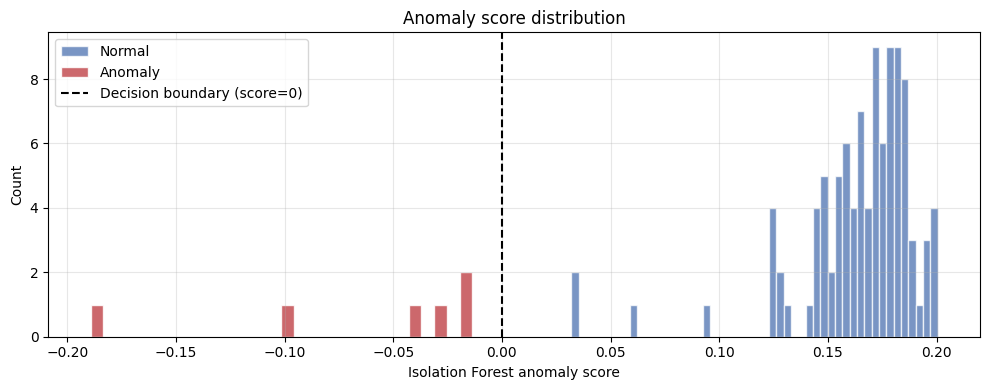

In [17]:
fig, ax = plt.subplots(figsize=(10, 4))
ax.hist(anomaly_scores[~is_anomaly], bins=50, alpha=0.75,
        color="#4C72B0", edgecolor="white", label="Normal")
ax.hist(anomaly_scores[is_anomaly],  bins=30, alpha=0.85,
        color="#C44E52", edgecolor="white", label="Anomaly")
ax.axvline(0, color="black", ls="--", lw=1.5, label="Decision boundary (score=0)")
ax.set_xlabel("Isolation Forest anomaly score")
ax.set_ylabel("Count")
ax.set_title("Anomaly score distribution")
ax.legend(fontsize=10)
fig.tight_layout()
plt.show()

## 10) Anomaly detection results

### Normal vs. flagged cycles side by side

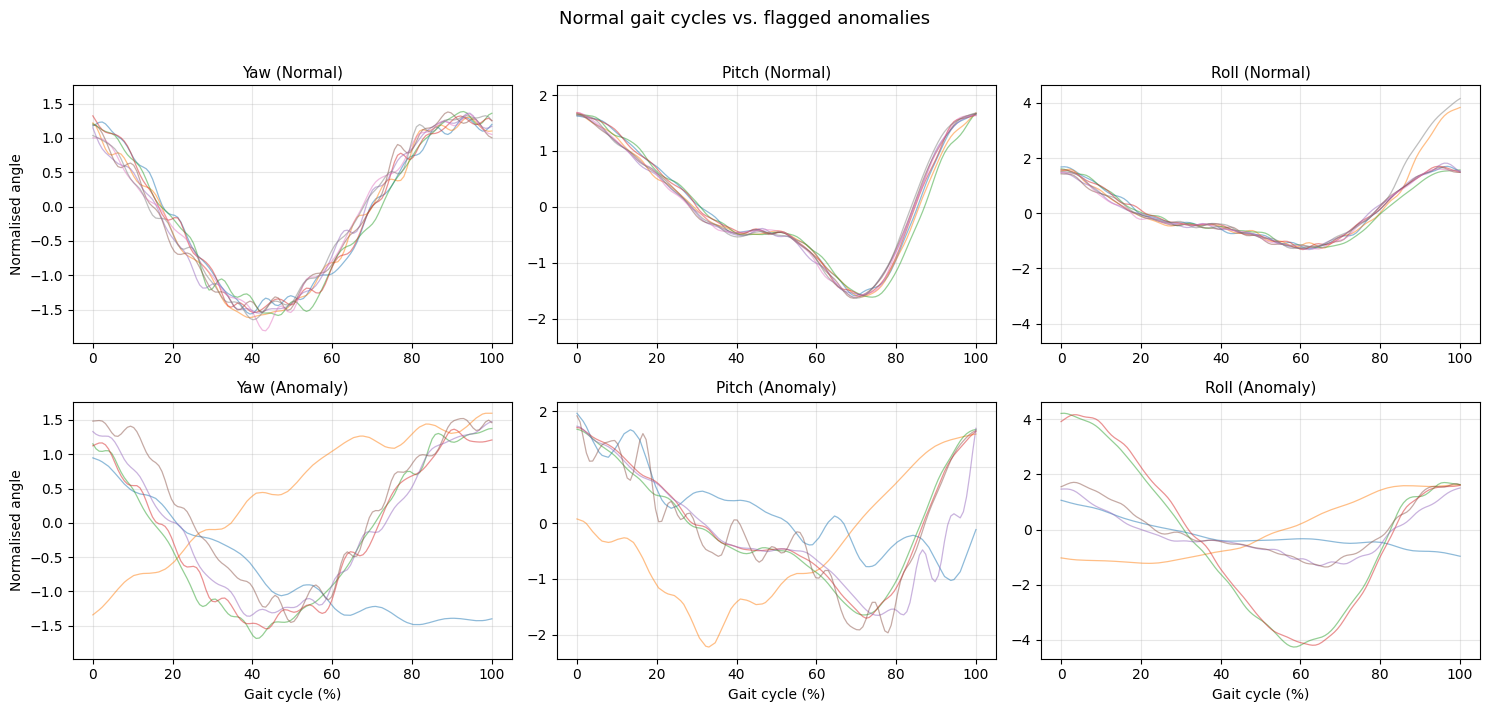

In [18]:
fig, axes = plt.subplots(2, 3, figsize=(15, 7), sharey="col")
channel_names = ["Yaw", "Pitch", "Roll"]
x_pct = np.linspace(0, 100, CYCLE_LENGTH)

# Sort anomaly indices by score (most anomalous first)
anomaly_idxs_sorted = anomaly_idxs[np.argsort(anomaly_scores[anomaly_idxs])]

# Top row: normal cycles
for ch in range(3):
    ax = axes[0, ch]
    for idx in normal_idxs[:8]:
        cycle = cycles_norm[idx]               # (T, 3)
        ax.plot(x_pct, cycle[:, ch], alpha=0.5, lw=0.9)
    ax.set_title(f"{channel_names[ch]} (Normal)", fontsize=11)
    if ch == 0:
        ax.set_ylabel("Normalised angle")

# Bottom row: flagged anomalies (most anomalous first)
for ch in range(3):
    ax = axes[1, ch]
    for idx in anomaly_idxs_sorted[:8]:
        cycle = cycles_norm[idx]
        ax.plot(x_pct, cycle[:, ch], alpha=0.5, lw=0.9)
    ax.set_title(f"{channel_names[ch]} (Anomaly)", fontsize=11)
    ax.set_xlabel("Gait cycle (%)")
    if ch == 0:
        ax.set_ylabel("Normalised angle")

fig.suptitle("Normal gait cycles vs. flagged anomalies", fontsize=13, y=1.01)
fig.tight_layout()
plt.show()

### Anomaly score along the recording timeline

Plotting the score chronologically helps spot drifts, clusters of anomalies, or transitions in gait quality.

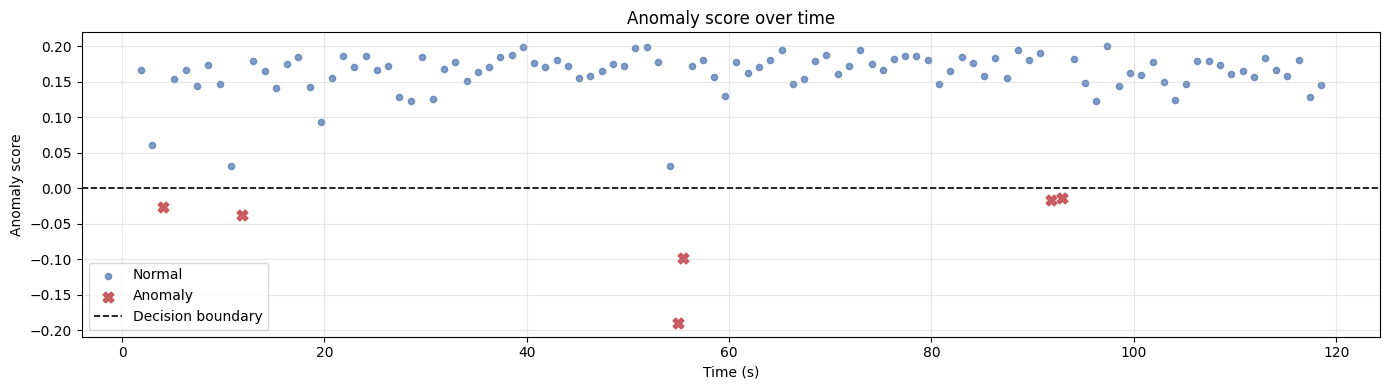

In [19]:
# Compute a representative timestamp per cycle (midpoint between consecutive heel strikes)
cycle_times = np.array([
    (timestamps[heel_strikes[i]] + timestamps[heel_strikes[i + 1]]) / 2
    for i in range(len(cycles))
])

fig, ax = plt.subplots(figsize=(14, 4))
ax.scatter(cycle_times[~is_anomaly], anomaly_scores[~is_anomaly],
           c="#4C72B0", s=20, alpha=0.7, label="Normal")
ax.scatter(cycle_times[is_anomaly],  anomaly_scores[is_anomaly],
           c="#C44E52", s=60, alpha=0.9, marker="X", label="Anomaly")
ax.axhline(0, color="black", ls="--", lw=1.2, label="Decision boundary")
ax.set_xlabel("Time (s)")
ax.set_ylabel("Anomaly score")
ax.set_title("Anomaly score over time")
ax.legend()
fig.tight_layout()
plt.show()

## 11) Feature importance (permutation-based)

Isolation Forest doesn't provide built-in feature importances, but we can estimate them by measuring how much the anomaly score changes when each feature is shuffled. Features that matter most will cause the biggest drop in score separation when permuted.

Computing permutation importances (stat features only)…


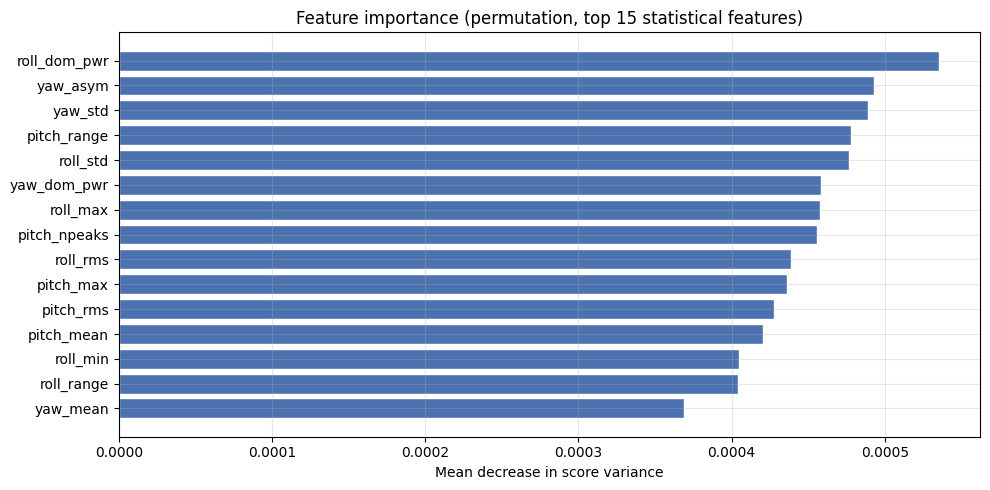

In [20]:
def permutation_importance_if(model, X, n_repeats=10, seed=42):
    """
    Estimate feature importance for an Isolation Forest via permutation.
    Importance = mean decrease in score variance when feature is shuffled.

    Returns
    -------
    importances : np.ndarray, shape (n_features,)
    """
    rng = np.random.default_rng(seed)
    baseline_scores = model.decision_function(X)
    baseline_var    = np.var(baseline_scores)

    importances = np.zeros(X.shape[1])
    for feat in range(X.shape[1]):
        decreases = []
        for _ in range(n_repeats):
            X_perm = X.copy()
            X_perm[:, feat] = rng.permutation(X_perm[:, feat])
            perm_scores = model.decision_function(X_perm)
            decreases.append(baseline_var - np.var(perm_scores))
        importances[feat] = np.mean(decreases)

    return importances


# Only run over stat features (interpretable names)
if FEATURE_MODE in ("statistical", "both"):
    print("Computing permutation importances (stat features only)…")
    stat_X_scaled = feature_scaler.transform(
        np.hstack([stat_features, np.zeros((len(stat_features), X_scaled.shape[1] - stat_features.shape[1]))])
    )[:, :stat_features.shape[1]]

    # Build a forest on just the stat features for cleaner attribution
    iso_stat = IsolationForest(n_estimators=100, contamination=CONTAMINATION,
                               random_state=SEED, n_jobs=-1)
    iso_stat.fit(stat_X_scaled)
    imp = permutation_importance_if(iso_stat, stat_X_scaled, n_repeats=5)

    order = np.argsort(imp)[::-1][:15]   # top-15 features
    fig, ax = plt.subplots(figsize=(10, 5))
    ax.barh([stat_feature_names[i] for i in order[::-1]],
            imp[order[::-1]], color="#4C72B0", edgecolor="white")
    ax.set_xlabel("Mean decrease in score variance")
    ax.set_title("Feature importance (permutation, top 15 statistical features)")
    fig.tight_layout()
    plt.show()
else:
    print("Permutation importance skipped (set FEATURE_MODE to 'statistical' or 'both')")

## 12) Latent-space visualisation (t-SNE)

Project the feature vectors to 2D with t-SNE to see whether normal and anomalous cycles actually land in different regions.

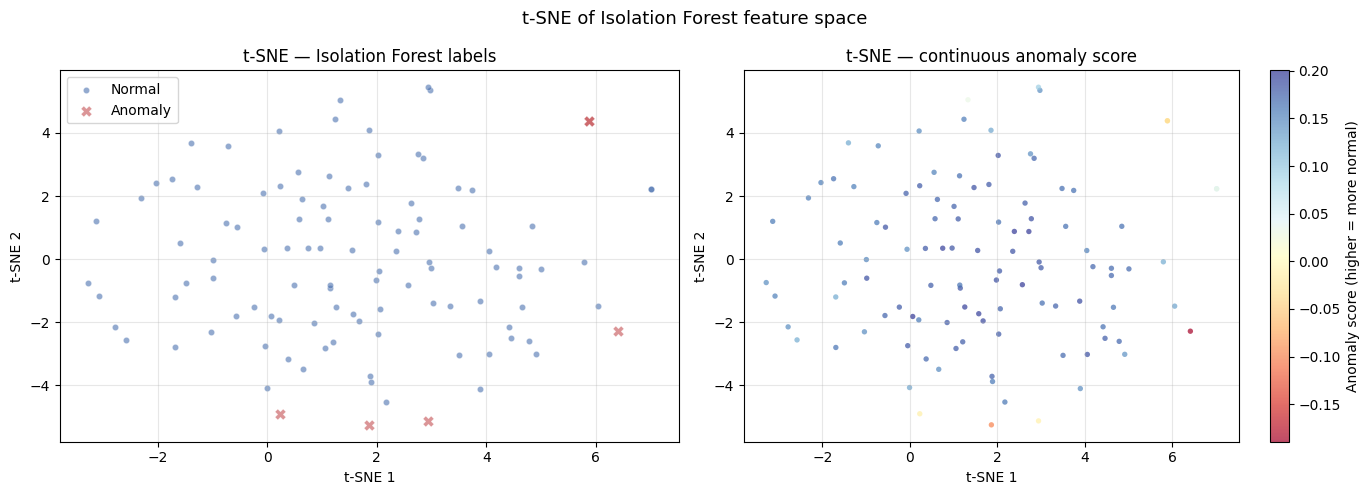

In [21]:
tsne = TSNE(n_components=2, perplexity=30, random_state=SEED, n_iter=1000)
proj = tsne.fit_transform(X_scaled)

tsne_labels = np.where(is_anomaly, "Anomaly", "Normal")

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Left: coloured by Isolation Forest label
ax = axes[0]
for label, color, marker in [("Normal", "#4C72B0", "o"), ("Anomaly", "#C44E52", "X")]:
    mask = tsne_labels == label
    ax.scatter(proj[mask, 0], proj[mask, 1], c=color, marker=marker,
               s=20 if label == "Normal" else 60, alpha=0.6, label=label,
               edgecolors="white", lw=0.3)
ax.set_title("t-SNE — Isolation Forest labels")
ax.legend()
ax.set_xlabel("t-SNE 1")
ax.set_ylabel("t-SNE 2")

# Right: coloured by continuous anomaly score
ax = axes[1]
sc = ax.scatter(proj[:, 0], proj[:, 1], c=anomaly_scores,
                cmap="RdYlBu", s=15, alpha=0.7, edgecolors="none")
plt.colorbar(sc, ax=ax, label="Anomaly score (higher = more normal)")
ax.set_title("t-SNE — continuous anomaly score")
ax.set_xlabel("t-SNE 1")
ax.set_ylabel("t-SNE 2")

fig.suptitle("t-SNE of Isolation Forest feature space", fontsize=13)
fig.tight_layout()
plt.show()

## 13) Inference on new recordings

This function wraps the full pipeline: load CSV → filter → segment → resample → normalise → extract features → score with Isolation Forest. Returns a DataFrame with one row per detected gait cycle.

In [22]:
def analyse_recording(csv_path, iso_forest, feature_scaler, pca,
                      chan_mean, chan_std, feature_mode=FEATURE_MODE,
                      fs=SAMPLING_RATE):
    """
    End-to-end inference on a new CSV recording.

    Returns a DataFrame with columns:
        cycle_index, start_time, end_time, duration_s,
        anomaly_score, is_anomaly
    """
    df_new = pd.read_csv(csv_path)
    t   = df_new["Relative timestamp"].values
    ang = np.column_stack([df_new["yaw"].values,
                           df_new["pitch"].values,
                           df_new["roll"].values])

    # Filter
    if LOWPASS_CUTOFF > 0:
        for ch in range(3):
            ang[:, ch] = lowpass(ang[:, ch], LOWPASS_CUTOFF, fs)

    # Segment
    peaks, _ = find_peaks(ang[:, 1], distance=MIN_STRIDE_SAMPLES,
                          prominence=PITCH_PEAK_PROMINENCE)
    cyc, _   = extract_cycles(ang, peaks, CYCLE_LENGTH)

    # Normalise with training stats
    cyc_n = (cyc - chan_mean) / chan_std

    # Extract features
    sf, _ = extract_statistical_features(cyc_n)
    flat  = cyc_n.reshape(len(cyc_n), -1)
    pf    = pca.transform(flat)

    if feature_mode == "statistical":
        feats = sf
    elif feature_mode == "pca_flat":
        feats = pf
    else:
        feats = np.hstack([sf, pf])

    feats_s = feature_scaler.transform(feats)

    # Score
    scores = iso_forest.decision_function(feats_s)
    flags  = iso_forest.predict(feats_s) == -1

    rows = []
    for i in range(len(cyc)):
        rows.append({
            "cycle_index":   i,
            "start_time":    t[peaks[i]],
            "end_time":      t[peaks[i + 1]],
            "duration_s":    t[peaks[i + 1]] - t[peaks[i]],
            "anomaly_score": scores[i],
            "is_anomaly":    flags[i],
        })
    return pd.DataFrame(rows)

# Example usage (uncomment with a real file):
# results = analyse_recording("new_walk.csv", iso_forest, feature_scaler, pca,
#                             chan_mean, chan_std)
# print(results[results["is_anomaly"]])

## 14) Per-channel anomaly breakdown

For flagged cycles, visualising how each channel's statistical features compare to the normal population helps identify *which* plane of motion is unusual — sagittal (pitch), frontal (roll), or transverse (yaw).

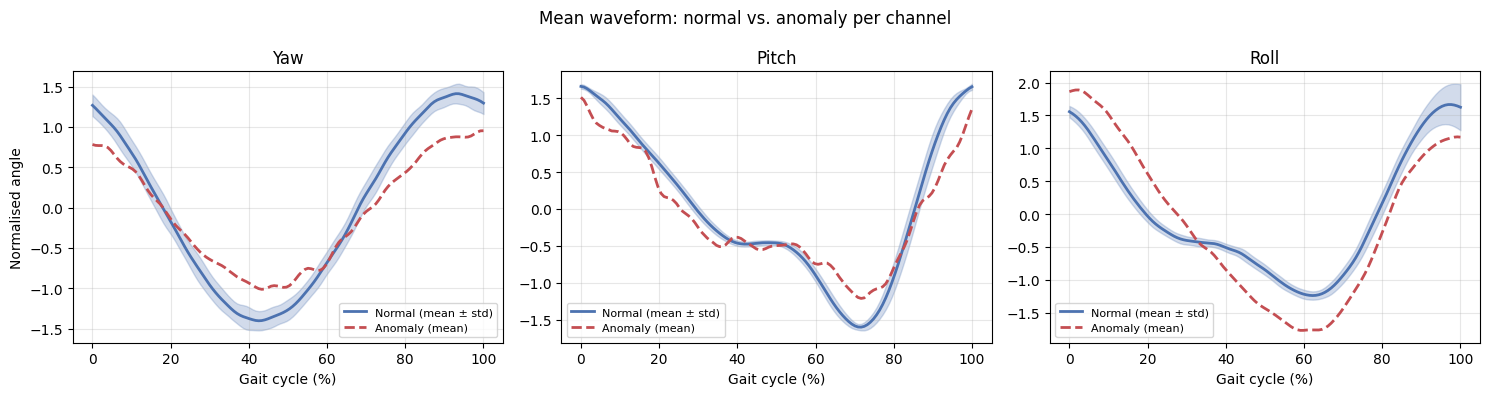

In [23]:
# Compare mean waveform per channel: normals vs anomalies
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
x_pct = np.linspace(0, 100, CYCLE_LENGTH)
channel_names = ["Yaw", "Pitch", "Roll"]

for ch, (ax, name) in enumerate(zip(axes, channel_names)):
    normal_mean  = cycles_norm[normal_idxs, :, ch].mean(axis=0)
    normal_std   = cycles_norm[normal_idxs, :, ch].std(axis=0)
    anomaly_mean = cycles_norm[anomaly_idxs, :, ch].mean(axis=0) if len(anomaly_idxs) else None

    ax.fill_between(x_pct, normal_mean - normal_std, normal_mean + normal_std,
                    alpha=0.25, color="#4C72B0")
    ax.plot(x_pct, normal_mean, color="#4C72B0", lw=2, label="Normal (mean ± std)")

    if anomaly_mean is not None:
        ax.plot(x_pct, anomaly_mean, color="#C44E52", lw=2, ls="--",
                label="Anomaly (mean)")

    ax.set_title(name)
    ax.set_xlabel("Gait cycle (%)")
    if ch == 0:
        ax.set_ylabel("Normalised angle")
    ax.legend(fontsize=8)

fig.suptitle("Mean waveform: normal vs. anomaly per channel", fontsize=12)
fig.tight_layout()
plt.show()

## 15) Save / load the trained model

In [24]:
SAVE_DIR = Path("checkpoints")
SAVE_DIR.mkdir(exist_ok=True)

checkpoint = {
    "iso_forest":    iso_forest,
    "feature_scaler": feature_scaler,
    "pca":           pca,
    "chan_mean":      chan_mean,
    "chan_std":       chan_std,
    "feature_mode":  FEATURE_MODE,
    "pca_components": PCA_COMPONENTS,
    "config": {
        "sampling_rate":          SAMPLING_RATE,
        "cycle_length":           CYCLE_LENGTH,
        "min_stride_samples":     MIN_STRIDE_SAMPLES,
        "pitch_peak_prominence":  PITCH_PEAK_PROMINENCE,
        "lowpass_cutoff":         LOWPASS_CUTOFF,
        "contamination":          CONTAMINATION,
        "n_estimators":           N_ESTIMATORS,
    },
}
save_path = SAVE_DIR / "gait_isolation_forest.joblib"
joblib.dump(checkpoint, save_path)
print(f"Checkpoint saved to {save_path}")

Checkpoint saved to checkpoints\gait_isolation_forest.joblib


In [25]:
# Load a saved checkpoint
def load_model(path):
    ckpt = joblib.load(path)
    return (ckpt["iso_forest"],
            ckpt["feature_scaler"],
            ckpt["pca"],
            ckpt["chan_mean"],
            ckpt["chan_std"],
            ckpt["feature_mode"],
            ckpt["config"])

iso_forest, feature_scaler, pca, chan_mean, chan_std, feature_mode, config = \
    load_model("checkpoints/gait_isolation_forest.joblib")

## 16) Next steps

The highest-impact improvements from here:

- **Collect more normal data** — Isolation Forest's contamination parameter is sensitive to the true anomaly rate; more clean data = more reliable boundary.
- **Tune `contamination`** — if you start getting manual labels from clinical review of flagged cycles, use them to calibrate this parameter.
- **Active labelling loop** — have someone review just the most anomalous cycles (lowest scores). After a few hundred labels per anomaly class, train a supervised classifier on top of the same features.
- **Combine with the Autoencoder** — the IF score and the reconstruction error are complementary signals; an ensemble (e.g. weighted average of normalised scores) can be more robust than either alone.
- **Per-foot analysis** — if you have bilateral sensors, run separate models per foot and compare the asymmetry between left and right anomaly scores.